# Advanced Analytics

## Mutual Fund Analytics Platform

### Tasks

- Historical VaR (95%) & CVaR
- Rolling 90-Day Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommendation System
- Sector HHI Concentration
- Advanced Business Insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [4]:
import os

print(os.getcwd())

c:\Users\REVANTH\OneDrive\Desktop\MF_Analytics\notebooks


In [3]:
import os

print(os.listdir("../data/processed"))

['02_nav_history_cleaned.csv', '07_scheme_performance_cleaned.csv', '08_investor_transactions_cleaned.csv']


In [4]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'live_nav_125497.csv', 'Nippon_Large_Cap.csv', 'SBI_Bluechip.csv']


In [5]:
import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")
aum_fund_house = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
monthly_sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv("../data/raw/05_category_inflows.csv")
industry_folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
scheme_performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
investor_transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio_holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [6]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum_fund_house,
    "Monthly SIP": monthly_sip,
    "Category Inflows": category_inflows,
    "Industry Folio": industry_folio,
    "Scheme Performance": scheme_performance,
    "Investor Transactions": investor_transactions,
    "Portfolio Holdings": portfolio_holdings,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
Monthly SIP: (48, 6)
Category Inflows: (144, 3)
Industry Folio: (21, 6)
Scheme Performance: (40, 19)
Investor Transactions: (32778, 13)
Portfolio Holdings: (322, 8)
Benchmark: (8050, 3)


In [7]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [8]:
scheme_performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [9]:
investor_transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [10]:
portfolio_holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [11]:

nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(["amfi_code", "date"])

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [12]:
nav_history.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [13]:
var_cvar = (
    nav_history
    .groupby("amfi_code")["daily_return"]
    .apply(
        lambda x: pd.Series({
            "VaR_95": x.quantile(0.05),
            "CVaR_95": x[x <= x.quantile(0.05)].mean()
        })
    )
    .unstack()
    .reset_index()
)

In [14]:
var_cvar = var_cvar.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [15]:
var_cvar.head()

,amfi_code,VaR_95,CVaR_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [17]:
import os

os.makedirs("../outputs", exist_ok=True)

In [18]:
var_cvar.to_csv(
    "../outputs/var_cvar_report.csv",
    index=False
)

In [19]:
import os

print(os.listdir("../outputs"))

['var_cvar_report.csv']


## Task 1: Historical VaR (95%) & CVaR

Calculated the 95% Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR) for all mutual fund schemes using daily NAV returns.

- VaR (95%) = 5th percentile of daily returns
- CVaR = Average of returns below the VaR threshold

2

In [20]:
scheme_performance.sort_values(
    "aum_crore",
    ascending=False
)[["amfi_code", "scheme_name", "aum_crore"]].head()

,amfi_code,scheme_name,aum_crore
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,49046
21,120842,Kotak Emerging Equity Fund - Regular - Growth,47469
17,118634,Nippon India Small Cap Fund - Regular - Growth,43630
37,149322,DSP Top 100 Equity Fund - Regular - Growth,41828
32,102886,UTI Mid Cap Fund - Regular - Growth,41728


In [21]:
top5_funds = scheme_performance.sort_values(
    "aum_crore",
    ascending=False
).head(5)["amfi_code"]

top5_funds

35    148568
21    120842
17    118634
37    149322
32    102886
Name: amfi_code, dtype: int64

In [22]:
rolling_data = nav_history[
    nav_history["amfi_code"].isin(top5_funds)
].copy()

rolling_data.head()

,amfi_code,date,nav,daily_return
36800,102886,2022-01-03,119.2905,NaN
36801,102886,2022-01-04,120.6402,0.011314
36802,102886,2022-01-05,121.4580,0.006779
36803,102886,2022-01-06,125.2386,0.031127
36804,102886,2022-01-07,124.1321,-0.008835


In [23]:
rolling_data["daily_return"] = (
    rolling_data
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [24]:
rolling_data["rolling_sharpe"] = (
    rolling_data
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        x.rolling(90).mean()
        /
        x.rolling(90).std()
        *
        (252 ** 0.5)
    )
)

In [25]:
rolling_data.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
36800,102886,2022-01-03,119.2905,NaN,NaN
36801,102886,2022-01-04,120.6402,0.011314,NaN
36802,102886,2022-01-05,121.4580,0.006779,NaN
36803,102886,2022-01-06,125.2386,0.031127,NaN
36804,102886,2022-01-07,124.1321,-0.008835,NaN


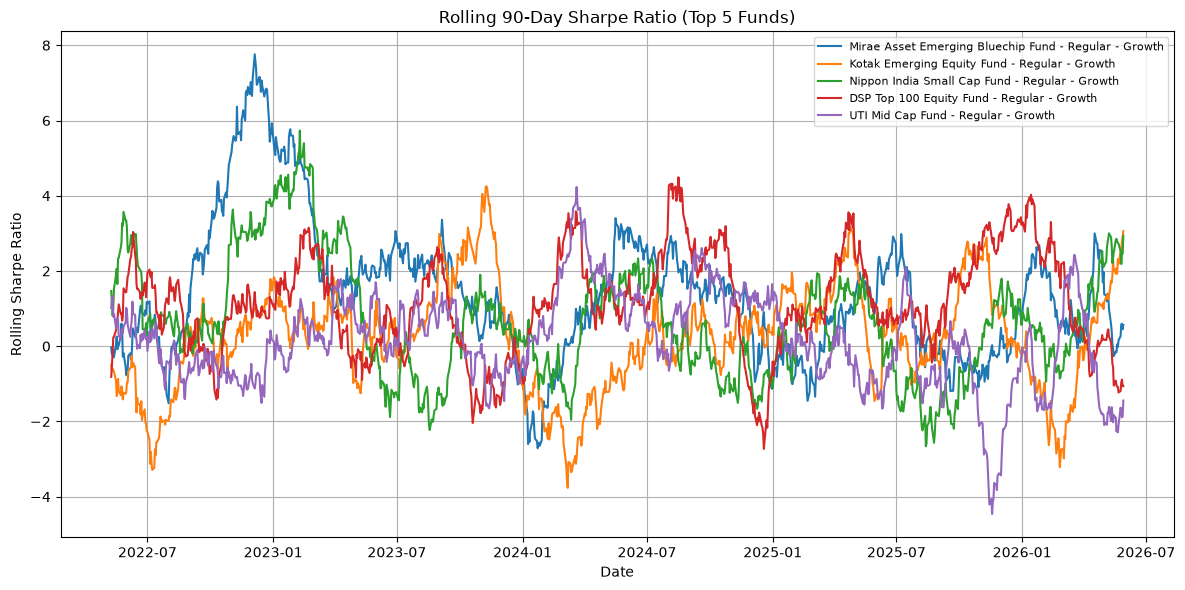

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in top5_funds:
    
    temp = rolling_data[
        rolling_data["amfi_code"] == fund
    ]
    
    fund_name = scheme_performance.loc[
        scheme_performance["amfi_code"] == fund,
        "scheme_name"
    ].values[0]
    
    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=fund_name
    )

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/rolling_sharpe_chart.png", dpi=300)

plt.show()

In [27]:
import os

print(os.listdir("../outputs"))

['rolling_sharpe_chart.png', 'var_cvar_report.csv']


## Task 2: Rolling 90-Day Sharpe Ratio

Calculated the rolling 90-day Sharpe Ratio for the top 5 mutual funds based on Assets Under Management (AUM). The chart illustrates the risk-adjusted performance of each fund over time using a 90-day rolling window.

3

In [28]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

In [29]:
first_txn = (
    investor_transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index(name="cohort_year")
)

first_txn.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [30]:
cohort = investor_transactions.merge(
    first_txn,
    on="investor_id",
    how="left"
)

cohort.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [31]:
cohort_summary = (
    cohort
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [32]:
top_fund = (
    cohort
    .groupby(["cohort_year","amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund
    .sort_values(
        ["cohort_year","count"],
        ascending=[True,False]
    )
    .drop_duplicates("cohort_year")
)

top_fund.head()

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [33]:
top_fund = top_fund.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_fund.head()

,cohort_year,amfi_code,count,scheme_name
0,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth


In [34]:
cohort_report = cohort_summary.merge(
    top_fund[
        ["cohort_year","scheme_name"]
    ],
    on="cohort_year"
)

cohort_report

,cohort_year,avg_sip_amount,total_invested,scheme_name
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,SBI Small Cap Fund - Direct Plan - Growth


## Task 3: Investor Cohort Analysis

Grouped investors based on their first transaction year (cohort) and calculated:

- Average SIP Amount
- Total Investment
- Most Preferred Mutual Fund

This analysis helps understand investment behavior across different investor cohorts.

4

In [35]:
sip_txn = investor_transactions[
    investor_transactions["transaction_type"] == "SIP"
].copy()

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [36]:
sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

In [37]:
sip_txn["gap_days"] = (
    sip_txn
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [38]:
sip_summary = (
    sip_txn
    .groupby("investor_id")
    .agg(
        sip_count=("transaction_date","count"),
        avg_gap=("gap_days","mean")
    )
    .reset_index()
)

In [39]:
sip_summary = sip_summary[
    sip_summary["sip_count"] >= 6
]

In [41]:
sip_summary.head()

,investor_id,sip_count,avg_gap
3,INV000004,6,85.400000
7,INV000008,6,70.400000
9,INV000010,6,64.800000
10,INV000011,7,40.166667
11,INV000012,8,57.000000


In [42]:
sip_summary["status"] = sip_summary["avg_gap"].apply(
    lambda x: "At-Risk" if x > 35 else "Active"
)

sip_summary.head()

,investor_id,sip_count,avg_gap,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


## Task 4: SIP Continuity Analysis

Analyzed investors with at least 6 SIP transactions by calculating the average gap between consecutive SIP dates.

- Investors with an average gap greater than 35 days are flagged as **At-Risk**.
- Others are classified as **Active**.

5

In [44]:
scheme_performance["risk_grade"].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [54]:
risk = input("Enter Risk Appetite (Low/Moderate/High): ").strip().title()

In [55]:
if risk == "Low":
    risk_filter = ["Low"]

elif risk == "Moderate":
    risk_filter = ["Moderate"]

elif risk == "High":
    risk_filter = ["High", "Very High", "Moderately High"]

else:
    print("Invalid Risk Appetite")
    risk_filter = []

In [56]:
recommendation = (
    scheme_performance[
        scheme_performance["risk_grade"].isin(risk_filter)
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(3)
)

In [57]:
print(recommendation[
    [
        "scheme_name",
        "fund_house",
        "risk_grade",
        "sharpe_ratio",
        "return_3yr_pct",
        "aum_crore"
    ]
].to_string(index=False))

                             scheme_name               fund_house risk_grade  sharpe_ratio  return_3yr_pct  aum_crore
ICICI Pru Liquid Fund - Regular - Growth      ICICI Prudential MF        Low          7.68            7.68      39116
    Kotak Liquid Fund - Regular - Growth        Kotak Mahindra MF        Low          6.18            6.18      27623
     ABSL Liquid Fund - Regular - Growth Aditya Birla Sun Life MF        Low          5.14            5.14      38995


## Task 5: Simple Fund Recommender

Implemented a rule-based mutual fund recommender.

**Input:** Risk Appetite (Low / Moderate / High)

**Output:** Top 3 mutual funds with the highest Sharpe Ratio within the selected risk category. 

6

In [58]:
portfolio_holdings["weight_decimal"] = (
    portfolio_holdings["weight_pct"] / 100
)

portfolio_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight_decimal
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


In [59]:
hhi = (
    portfolio_holdings
    .groupby("amfi_code")
    .agg(
        HHI=("weight_decimal",
             lambda x: (x ** 2).sum())
    )
    .reset_index()
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [60]:
hhi = hhi.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [61]:
hhi = hhi.sort_values(
    "HHI",
    ascending=False
)

hhi.head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


# Advanced Business Insights

### 1. Historical Risk Analysis
ABSL Small Cap Fund and similar equity funds showed higher downside risk (VaR/CVaR), indicating greater potential losses during adverse market conditions.

### 2. Risk-Adjusted Performance
The Rolling 90-Day Sharpe Ratio shows that the top funds consistently delivered strong risk-adjusted returns, although performance varied across different market periods.

### 3. Investor Cohort Behavior
The 2024 investor cohort contributed the highest total investment amount, while Mirae Asset Emerging Bluechip Fund emerged as the most preferred fund.

### 4. SIP Continuity
Several investors with more than six SIP transactions had an average investment gap greater than 35 days and were identified as **At-Risk**, indicating possible discontinuation of SIP investments.

### 5. Portfolio Concentration
Axis Bluechip Fund recorded the highest HHI among the analyzed equity funds, indicating a relatively concentrated portfolio compared with other funds.